# Two-Point Correlation Function (2PCF) Analysis

This notebook computes the two-point correlation function ξ(r) using the Corrfunc library with periodic boundary conditions.

- **Subvolumes**: 1024 independent random realizations of the same 542³ Mpc³/h³ box
- **Periodic Box**: Corrfunc applies periodic boundary conditions with box size = 542 Mpc/h
- **Max Scale**: rmax < boxsize/2 ≈ 271 Mpc/h to avoid double-counting pairs

## Load Libraries

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from utils.matplotlib_config import register_matplotlib_setconfig
from config import get_base_dir
import analysis.correlation.correlation as corr_module
import importlib
corr_module = importlib.reload(corr_module)

correlation_given_redshift_and_subvolume = corr_module.correlation_given_redshift_and_subvolume
avg_correlation_given_redshift_and_subvolumes = corr_module.avg_correlation_given_redshift_and_subvolumes
correlations_given_redshifts_and_subvolume = corr_module.correlations_given_redshifts_and_subvolume
avg_correlation_given_subvolume_and_redshifts = corr_module.avg_correlation_given_subvolume_and_redshifts

base_dir = get_base_dir()
register_matplotlib_setconfig(mpl)
mpl.setconfig()

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## 2PCF for a given snapshot and subvolume

In [5]:
# Compute correlation data for a single snapshot/subvolume
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(200.0), 20)

# Minimum halo mass cut (Msun)
mhalo_min = 1e11  #  Msun

result = correlation_given_redshift_and_subvolume(
    snap_path,
    example_ivol,
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
 )

z = result.attrs.get('z')
ngal = result.attrs.get('ngal')
boxsize = result.attrs.get('boxsize')
V_ivol = result.attrs.get('V_ivol')

r = result['r'].to_numpy()
xi = result['xi'].to_numpy()

print(f"z={z:.2f}, N_halo={ngal}, boxsize={boxsize:.1f} Mpc/h, V_ivol={V_ivol:.2e} (Mpc/h)^3")

z=0.50, N_halo=4198, boxsize=542.0 Mpc/h, V_ivol=1.56e+05 (Mpc/h)^3


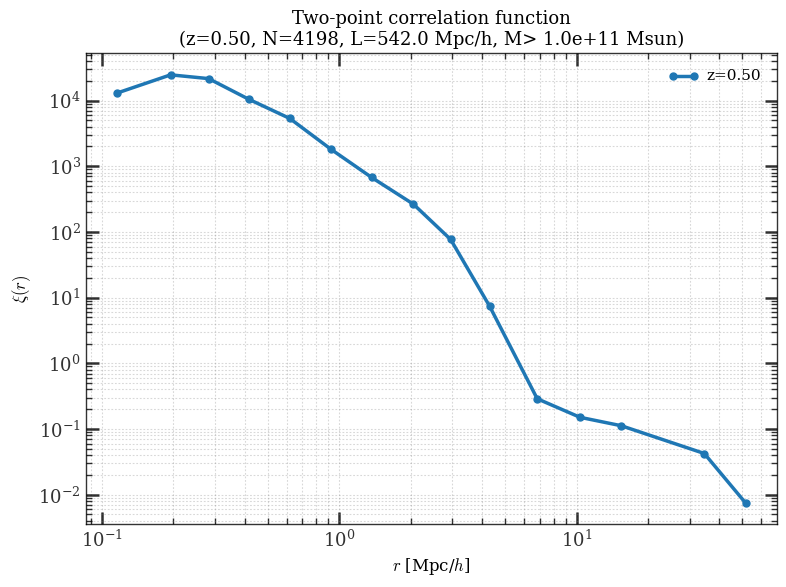

In [ ]:
r = result['r'].to_numpy()
xi = result['xi'].to_numpy()
z = result.attrs.get('z')
ngal = result.attrs.get('ngal')
boxsize = result.attrs.get('boxsize')

fig, ax = plt.subplots(figsize=(8, 6))

# Plot only positive, finite values on log-log scale
mask = (r > 0) & (xi > 0) & np.isfinite(r) & np.isfinite(xi)
ax.loglog(r[mask], xi[mask], 'o-', markersize=5, label=f'z={z:.2f}')

ax.set_xlabel(r'$r$ [Mpc/$h$]', fontsize=12)
ax.set_ylabel(r'$\xi(r)$', fontsize=12)
ax.set_title(f'Two-point correlation function\n(z={z:.2f}, N={ngal}, L={boxsize:.1f} Mpc/h, M> {mhalo_min:.1e} Msun)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 2PCF for one subvolume across multiple redshifts (overlay)

In [7]:
# Compute correlation for multiple redshifts
iz_nums = [100, 120, 142, 176, 207]
example_ivol = 100

results = []
for iz_num in iz_nums:
    iz_path = str(base_dir / f'iz{iz_num}')
    res = correlation_given_redshift_and_subvolume(
        iz_path,
        example_ivol,
        rbins=rbins,
        nthreads=4,
        mhalo_min=mhalo_min,
    )
    if res is not None:
        res.attrs['iz'] = f'iz{iz_num}'
        results.append(res)
        print(f"iz{iz_num}: z={res.attrs.get('z'):.3f}, N={res.attrs.get('ngal')}")
    else:
        print(f"iz{iz_num}: failed")


iz100: failed
iz120: failed
iz142: failed
iz176: z=1.007, N=4085
iz207: z=0.496, N=4198


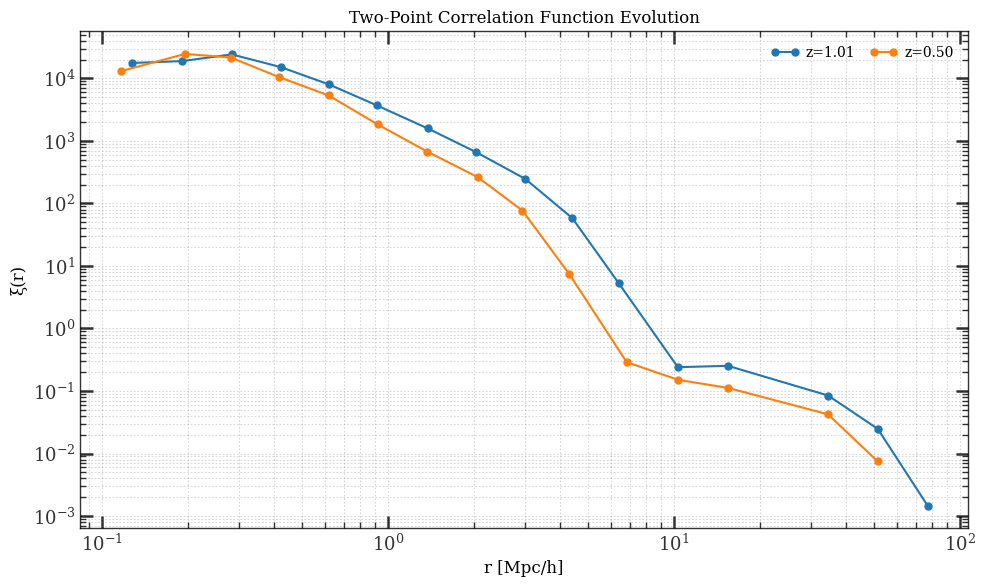

In [ ]:
plt.figure(figsize=(10, 6))

for i, res in enumerate(results):
    r = res['r'].to_numpy()
    xi = res['xi'].to_numpy()
    z = res.attrs.get('z')
    iz = res.attrs.get('iz')
    label = f"z={z:.2f}" if z is not None else (iz if iz is not None else f"snapshot {i}")
    mask = (r > 0) & (xi > 0) & np.isfinite(r) & np.isfinite(xi)
    plt.loglog(r[mask], xi[mask], 'o-', label=label, markersize=5, linewidth=1.5)

plt.xlabel('r [Mpc/h]', fontsize=12)
plt.ylabel('ξ(r)', fontsize=12)
plt.title('Two-Point Correlation Function Evolution', fontsize=12)
plt.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

## Average 2PCF over multiple redshifts for one subvolume

In [9]:
# Average over redshifts for a single subvolume
example_ivol = 40
iz_nums = [100, 120, 142, 176, 207]

avg_result = avg_correlation_given_subvolume_and_redshifts(
    iz_nums=iz_nums,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    base_dir=str(base_dir),
    mhalo_min=mhalo_min,
 )

print(f"Data computed: averaged over {len(iz_nums)} redshifts for ivol {example_ivol}")

Data computed: averaged over 5 redshifts for ivol 40


## 2PCF averaged over multiple subvolumes at different redshifts

In [12]:
# Average correlation across multiple subvolumes for each redshift
iz_nums = [100, 120, 176, 207]
example_ivols = [40, 60]  # Two subvolumes for averaging
results_multi = []
for iz_num in iz_nums:
    result = avg_correlation_given_redshift_and_subvolumes(
        iz_num=iz_num,
        ivols=example_ivols,
        rbins=rbins,
        nthreads=4,
        base_dir=str(base_dir),
        mhalo_min=mhalo_min,
    )

    results_multi.append(result)
    if result is not None:
        print(f"iz{iz_num}: z={result.attrs.get('z'):.2f}, avg over {result.attrs.get('n_used')} ivols")

iz100: z=4.30, avg over 1 ivols
iz120: z=3.05, avg over 2 ivols
iz176: z=1.01, avg over 2 ivols
iz207: z=0.50, avg over 2 ivols


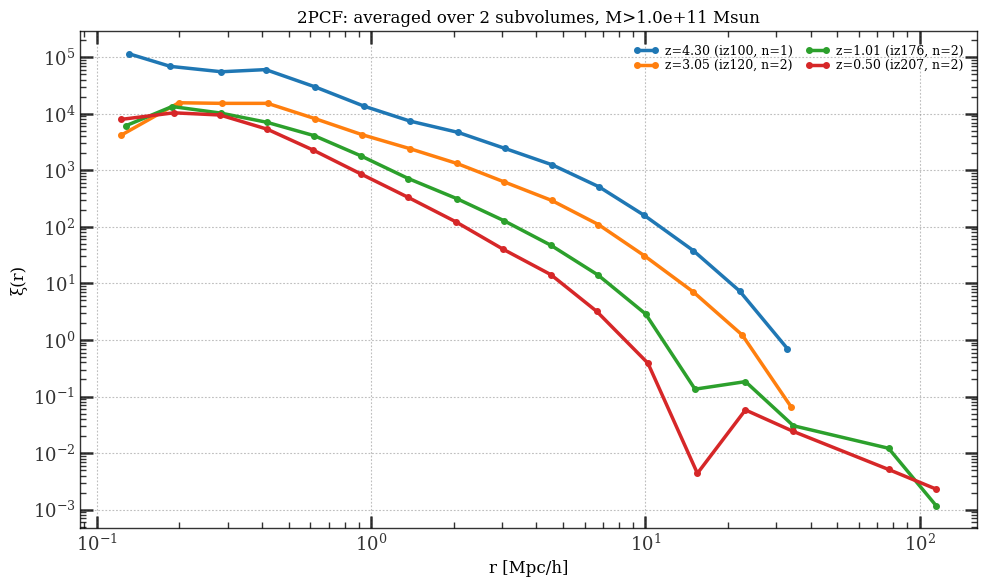

In [ ]:
plt.figure(figsize=(10, 6))

for i, res in enumerate(results_multi):
    r = res['r'].to_numpy()
    xi = res['xi'].to_numpy()
    xi_std = res['xi_std'].to_numpy() if 'xi_std' in res.columns else None
    z = res.attrs.get('z')
    iz = res.attrs.get('iz')
    n_used = res.attrs.get('n_used')
    label = f"z={z:.2f} ({iz}, n={n_used})" if z is not None else f"{iz}"
    mask = (r > 0) & (xi > 0) & np.isfinite(r) & np.isfinite(xi)
    plt.loglog(r[mask], xi[mask], 'o-', label=label, markersize=4)
    if xi_std is not None:
        plt.fill_between(r[mask], xi[mask] - xi_std[mask], xi[mask] + xi_std[mask], alpha=0.15)

plt.xlabel('r [Mpc/h]', fontsize=12)
plt.ylabel('ξ(r)', fontsize=12)
plt.title(f'2PCF: averaged over {len(example_ivols)} subvolumes, M>{mhalo_min:.1e} Msun', fontsize=12)
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()